# 03_preparacao_sequencias_rio_doce.ipynb
#
# Objetivo:
# analisar os artefatos gerados pela Fase 3A do Estudo de Caso 2,
# validando a transformação da base de features em dataset sequencial
# supervisionado para uso posterior na LSTM.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

# 1. Garante que estamos apontando para a raiz do projeto (FrameWork_MLOps_Unificado)
def encontrar_raiz(caminho_atual=Path.cwd().resolve()):
    for pai in [caminho_atual] + list(caminho_atual.parents):
        if (pai / "src").exists() or (pai / "data").exists():
            return pai
    return caminho_atual.parents[1]

RAIZ_PROJETO = encontrar_raiz()

# 2. Constrói os caminhos absolutos unindo a raiz com o caminho relativo
caminho_base_features = RAIZ_PROJETO / "data/processed/river_level/dataset_features_baseline_lstm.csv"
caminho_dataset_sequencial = RAIZ_PROJETO / "data/processed/river_level/dataset_sequencial_baseline_lstm.npz"
caminho_resumo = RAIZ_PROJETO / "artifacts/river_level/baseline_lstm/sequencias/resumo_sequencias_baseline_lstm.json"

# 3. Verifica se os arquivos foram encontrados
print(caminho_base_features.exists(), caminho_base_features)
print(caminho_dataset_sequencial.exists(), caminho_dataset_sequencial)
print(caminho_resumo.exists(), caminho_resumo)

True C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado\data\processed\river_level\dataset_features_baseline_lstm.csv
True C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado\data\processed\river_level\dataset_sequencial_baseline_lstm.npz
True C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado\artifacts\river_level\baseline_lstm\sequencias\resumo_sequencias_baseline_lstm.json


In [3]:
df_features = pd.read_csv(
    caminho_base_features,
    parse_dates=["Data"],
    index_col="Data",
    encoding="utf-8-sig",
).sort_index()

dataset = np.load(caminho_dataset_sequencial, allow_pickle=True)

with open(caminho_resumo, "r", encoding="utf-8") as arquivo:
    resumo = json.load(arquivo)

In [4]:
df_features.head()

,Nivel,Precip_Media_Estacoes,Precip_Log,API,Dias_Estiagem_<5mm,Dias_Estiagem_<10mm,Dias_Estiagem_<15mm,Nivel_Media_3d,Nivel_Tendencia_3d,Nivel_Media_7d,...,Precip_Log_Lag_90d,API_Lag_1d,API_Lag_3d,API_Lag_7d,API_Lag_15d,API_Lag_30d,API_Lag_60d,API_Lag_90d,Seno_DiaAno,Cosseno_DiaAno
Data,,,,,,,,,,,,,,,,,,,,,
2005-04-01,4.05,8.6985,2.271971,42.462911,0,11,11,4.130000,-0.17,4.172857,...,0.174373,46.086316,53.672561,61.884708,75.212923,120.547094,109.303836,0.190500,0.999986,0.005376
2005-04-02,4.05,0.6350,0.491643,47.764378,1,12,12,4.076667,-0.16,4.152857,...,2.589041,42.462911,49.886756,56.933932,69.195889,124.872827,101.067530,0.365760,0.999930,-0.011826
2005-04-03,4.03,56.3925,4.049914,44.578228,0,0,0,4.043333,-0.10,4.127143,...,3.032426,47.764378,46.086316,56.634217,63.660218,143.905501,99.396627,12.653499,0.999579,-0.029025
2005-04-04,4.01,0.0000,0.000000,97.404469,1,1,1,4.030000,-0.04,4.100000,...,0.874218,44.578228,42.462911,52.611480,65.107401,132.456561,122.740897,31.388719,0.998932,-0.046215
2005-04-05,3.89,0.0000,0.000000,89.612112,2,2,2,3.976667,-0.16,4.052857,...,2.499508,97.404469,47.764378,53.672561,62.628809,121.923536,131.716625,30.274622,0.997989,-0.063391


In [5]:
resumo

{'etapa': 'preparacao_sequencias',
 'arquivo_configuracao': 'experiments\\river_level\\baseline_lstm.yaml',
 'base_features_entrada': 'data\\processed\\river_level\\dataset_features_baseline_lstm.csv',
 'dataset_sequencial_saida': 'data\\processed\\river_level\\dataset_sequencial_baseline_lstm.npz',
 'n_linhas_base_features': 7659,
 'n_colunas_base_features': 36,
 'coluna_alvo': 'Nivel',
 'n_colunas_entrada': 36,
 'colunas_entrada': ['Nivel',
  'Precip_Media_Estacoes',
  'Precip_Log',
  'API',
  'Dias_Estiagem_<5mm',
  'Dias_Estiagem_<10mm',
  'Dias_Estiagem_<15mm',
  'Nivel_Media_3d',
  'Nivel_Tendencia_3d',
  'Nivel_Media_7d',
  'Nivel_Tendencia_7d',
  'Nivel_Media_15d',
  'Nivel_Tendencia_15d',
  'Nivel_Lag_1d',
  'Nivel_Lag_3d',
  'Nivel_Lag_7d',
  'Nivel_Lag_15d',
  'Nivel_Lag_30d',
  'Nivel_Lag_60d',
  'Nivel_Lag_90d',
  'Precip_Log_Lag_1d',
  'Precip_Log_Lag_3d',
  'Precip_Log_Lag_7d',
  'Precip_Log_Lag_15d',
  'Precip_Log_Lag_30d',
  'Precip_Log_Lag_60d',
  'Precip_Log_Lag_90d'

In [6]:
X = dataset["X"]
y = dataset["y"]
datas_inicio_janela = dataset["datas_inicio_janela"]
datas_fim_janela = dataset["datas_fim_janela"]
datas_alvo = dataset["datas_alvo"]
colunas_entrada = dataset["colunas_entrada"]
coluna_alvo = dataset["coluna_alvo"][0]
indice_alvo_nas_entradas = int(dataset["indice_alvo_nas_entradas"][0])
passos_entrada = int(dataset["passos_entrada"][0])
horizonte_previsao = int(dataset["horizonte_previsao"][0])

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Coluna alvo:", coluna_alvo)
print("Passos de entrada:", passos_entrada)
print("Horizonte de previsão:", horizonte_previsao)
print("Número de colunas de entrada:", len(colunas_entrada))
print("Índice da coluna alvo nas entradas:", indice_alvo_nas_entradas)

Shape X: (7479, 180, 36)
Shape y: (7479,)
Coluna alvo: Nivel
Passos de entrada: 180
Horizonte de previsão: 1
Número de colunas de entrada: 36
Índice da coluna alvo nas entradas: 0


In [7]:
n_linhas_base = len(df_features)
n_amostras_esperadas = n_linhas_base - passos_entrada - horizonte_previsao + 1

print("Linhas da base de features:", n_linhas_base)
print("Amostras esperadas:", n_amostras_esperadas)
print("Amostras geradas:", len(y))

assert len(y) == n_amostras_esperadas, "Quantidade de amostras inconsistente."
assert X.shape[0] == len(y), "Número de amostras em X e y diverge."
assert X.shape[1] == passos_entrada, "Quantidade de passos da janela inconsistente."
assert X.shape[2] == len(colunas_entrada), "Número de features inconsistente."

Linhas da base de features: 7659
Amostras esperadas: 7479
Amostras geradas: 7479


In [8]:
print("NaN em X:", np.isnan(X).sum())
print("NaN em y:", np.isnan(y).sum())
print("Inf em X:", np.isinf(X).sum())
print("Inf em y:", np.isinf(y).sum())

assert np.isnan(X).sum() == 0
assert np.isnan(y).sum() == 0
assert np.isinf(X).sum() == 0
assert np.isinf(y).sum() == 0

NaN em X: 0
NaN em y: 0
Inf em X: 0
Inf em y: 0


In [9]:
print("Primeira janela começa em:", datas_inicio_janela[0])
print("Primeira janela termina em:", datas_fim_janela[0])
print("Primeiro alvo:", datas_alvo[0])

print("Última janela começa em:", datas_inicio_janela[-1])
print("Última janela termina em:", datas_fim_janela[-1])
print("Último alvo:", datas_alvo[-1])

Primeira janela começa em: 2005-04-01
Primeira janela termina em: 2005-09-27
Primeiro alvo: 2005-09-28
Última janela começa em: 2025-09-21
Última janela termina em: 2026-03-19
Último alvo: 2026-03-20


In [10]:
serie_alvo_base = df_features[coluna_alvo].copy()

data_alvo_0 = pd.to_datetime(datas_alvo[0])
valor_alvo_0_base = serie_alvo_base.loc[data_alvo_0]
valor_alvo_0_dataset = y[0]

print("Valor alvo na base:", valor_alvo_0_base)
print("Valor alvo no dataset:", valor_alvo_0_dataset)

assert np.isclose(valor_alvo_0_base, valor_alvo_0_dataset), "Primeiro alvo não confere com a base."

Valor alvo na base: 3.96
Valor alvo no dataset: 3.96


In [11]:
indice_teste = len(y) // 2

data_alvo_teste = pd.to_datetime(datas_alvo[indice_teste])
valor_alvo_teste_base = serie_alvo_base.loc[data_alvo_teste]
valor_alvo_teste_dataset = y[indice_teste]

print("Data alvo:", data_alvo_teste.date())
print("Valor alvo na base:", valor_alvo_teste_base)
print("Valor alvo no dataset:", valor_alvo_teste_dataset)

assert np.isclose(valor_alvo_teste_base, valor_alvo_teste_dataset), "Alvo intermediário não confere com a base."

Data alvo: 2015-12-24
Valor alvo na base: 2.44
Valor alvo no dataset: 2.44


In [12]:
df_primeira_janela = pd.DataFrame(
    X[0],
    columns=colunas_entrada,
)

df_primeira_janela.head()

,Nivel,Precip_Media_Estacoes,Precip_Log,API,Dias_Estiagem_<5mm,Dias_Estiagem_<10mm,Dias_Estiagem_<15mm,Nivel_Media_3d,Nivel_Tendencia_3d,Nivel_Media_7d,...,Precip_Log_Lag_90d,API_Lag_1d,API_Lag_3d,API_Lag_7d,API_Lag_15d,API_Lag_30d,API_Lag_60d,API_Lag_90d,Seno_DiaAno,Cosseno_DiaAno
0,4.05,8.698500,2.271971,42.462910,0.0,11.0,11.0,4.130000,-0.17,4.172857,...,0.174373,46.086315,53.672562,61.884708,75.212921,120.547096,109.303833,0.190500,0.999986,0.005376
1,4.05,0.635000,0.491643,47.764378,1.0,12.0,12.0,4.076667,-0.16,4.152857,...,2.589041,42.462910,49.886757,56.933933,69.195892,124.872826,101.067528,0.365760,0.999930,-0.011826
2,4.03,56.392502,4.049913,44.578228,0.0,0.0,0.0,4.043334,-0.10,4.127143,...,3.032426,47.764378,46.086315,56.634216,63.660217,143.905502,99.396629,12.653500,0.999579,-0.029025
3,4.01,0.000000,0.000000,97.404472,1.0,1.0,1.0,4.030000,-0.04,4.100000,...,0.874218,44.578228,42.462910,52.611481,65.107399,132.456558,122.740898,31.388720,0.998932,-0.046215
4,3.89,0.000000,0.000000,89.612114,2.0,2.0,2.0,3.976667,-0.16,4.052857,...,2.499508,97.404472,47.764378,53.672562,62.628807,121.923538,131.716629,30.274622,0.997989,-0.063391


In [13]:
df_primeira_janela.tail()

,Nivel,Precip_Media_Estacoes,Precip_Log,API,Dias_Estiagem_<5mm,Dias_Estiagem_<10mm,Dias_Estiagem_<15mm,Nivel_Media_3d,Nivel_Tendencia_3d,Nivel_Media_7d,...,Precip_Log_Lag_90d,API_Lag_1d,API_Lag_3d,API_Lag_7d,API_Lag_15d,API_Lag_30d,API_Lag_60d,API_Lag_90d,Seno_DiaAno,Cosseno_DiaAno
175,2.40,0.127000,0.119559,20.718367,4.0,4.0,112.0,2.776667,-0.58,2.832857,...,0.000000,22.519964,26.255651,20.366316,10.864210,16.923239,10.348968,27.741514,-0.990692,-0.136120
176,2.89,0.000000,0.000000,19.187897,5.0,5.0,113.0,2.746667,-0.09,2.834286,...,0.000000,20.718367,24.409199,18.800510,9.995073,15.569379,9.521050,25.522194,-0.992887,-0.119059
177,2.90,0.000000,0.000000,17.652864,6.0,6.0,114.0,2.730000,-0.05,2.852857,...,0.000000,19.187897,22.519964,17.296469,9.639967,14.387328,8.759366,23.480417,-0.994788,-0.101962
178,2.94,15.812000,2.822093,16.240637,0.0,0.0,0.0,2.910000,0.54,2.862857,...,0.061565,17.652864,20.718367,15.976252,8.868770,13.236342,8.058617,21.601984,-0.996395,-0.084835
179,3.24,25.717501,3.285319,30.753386,0.0,0.0,0.0,3.026667,0.35,2.900000,...,1.316542,16.240637,19.187897,26.255651,18.536697,12.177435,9.064927,19.937326,-0.997707,-0.067683


In [14]:
nome_coluna_alvo_entrada = colunas_entrada[indice_alvo_nas_entradas]
print("Coluna na posição do alvo dentro das entradas:", nome_coluna_alvo_entrada)

assert nome_coluna_alvo_entrada == coluna_alvo

Coluna na posição do alvo dentro das entradas: Nivel


In [15]:
ultimo_nivel_da_janela = X[0, -1, indice_alvo_nas_entradas]
primeiro_alvo = y[0]

print("Último valor de nível na janela:", ultimo_nivel_da_janela)
print("Valor alvo seguinte:", primeiro_alvo)

Último valor de nível na janela: 3.24
Valor alvo seguinte: 3.96


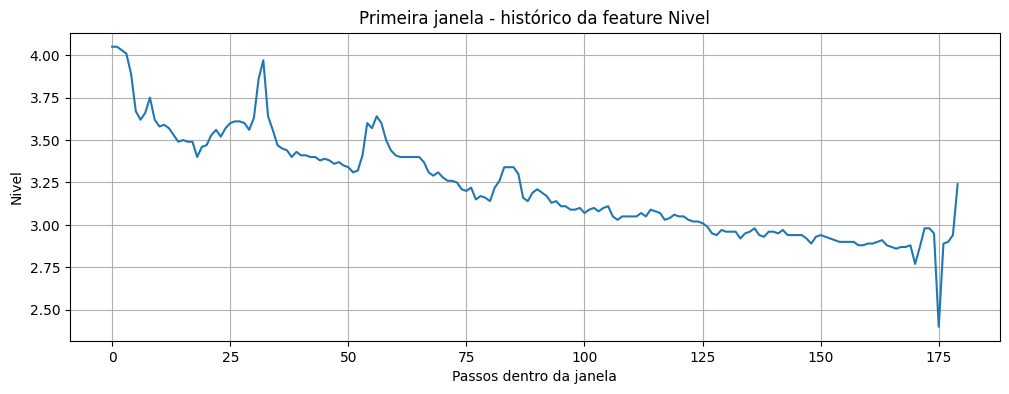

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(df_primeira_janela["Nivel"].values)
plt.title("Primeira janela - histórico da feature Nivel")
plt.xlabel("Passos dentro da janela")
plt.ylabel("Nivel")
plt.grid(True)
plt.show()

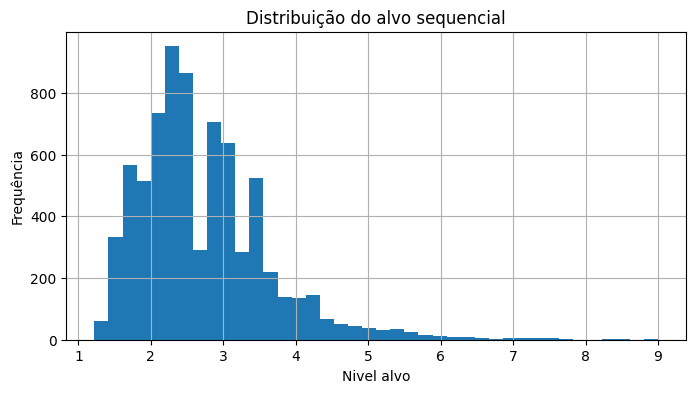

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(y, bins=40)
plt.title("Distribuição do alvo sequencial")
plt.xlabel("Nivel alvo")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

In [18]:
df_datas = pd.DataFrame({
    "data_inicio_janela": pd.to_datetime(datas_inicio_janela),
    "data_fim_janela": pd.to_datetime(datas_fim_janela),
    "data_alvo": pd.to_datetime(datas_alvo),
})

df_datas.head()

,data_inicio_janela,data_fim_janela,data_alvo
0,2005-04-01,2005-09-27,2005-09-28
1,2005-04-02,2005-09-28,2005-09-29
2,2005-04-03,2005-09-29,2005-09-30
3,2005-04-04,2005-09-30,2005-10-01
4,2005-04-05,2005-10-01,2005-10-02


In [19]:
df_datas["dias_janela"] = (
    df_datas["data_fim_janela"] - df_datas["data_inicio_janela"]
).dt.days + 1

df_datas["defasagem_alvo"] = (
    df_datas["data_alvo"] - df_datas["data_fim_janela"]
).dt.days

df_datas[["dias_janela", "defasagem_alvo"]].describe()

,dias_janela,defasagem_alvo
count,7479.0,7479.0
mean,180.0,1.0
std,0.0,0.0
min,180.0,1.0
25%,180.0,1.0
50%,180.0,1.0
75%,180.0,1.0
max,180.0,1.0


In [20]:
assert df_datas["dias_janela"].min() == passos_entrada
assert df_datas["dias_janela"].max() == passos_entrada
assert df_datas["defasagem_alvo"].min() == horizonte_previsao
assert df_datas["defasagem_alvo"].max() == horizonte_previsao

In [21]:
print("Validação da Fase 3A concluída com sucesso.")
print("O dataset sequencial está coerente e pronto para a próxima etapa.")

Validação da Fase 3A concluída com sucesso.
O dataset sequencial está coerente e pronto para a próxima etapa.
